In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [34]:
# build the dataset

block_size = 3 # context length: how many charcters do we take to predict the next one
X, Y = [], []

for w in words:
    # print(w)
    context = [0] * block_size

    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        # print(''.join(itos[i] for i in context), '----->', itos[ix])
        context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)

In [123]:
# build the dataset

def build_dataset(words):
    block_size = 3 # context length: how many charcters do we take to predict the next one
    X, Y = [], []

    for w in words:
        # print(w)
        context = [0] * block_size

        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            # print(''.join(itos[i] for i in context), '----->', itos[ix])
            context = context[1:] + [ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [35]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [36]:
C = torch.randn((27, 2))

In [37]:
# F.one_hot(torch.tensor(5), num_classes=27).float() @ C # will not be using this 
# C[5]
# C[[5,6,7]]
# C[torch.tensor([5,6,7])]
C[torch.tensor([5,6,7,7,7,7])]


tensor([[0.4255, 2.4248],
        [0.6674, 0.3229],
        [1.2192, 0.5930],
        [1.2192, 0.5930],
        [1.2192, 0.5930],
        [1.2192, 0.5930]])

In [38]:
# C[X].shape
# X[13,2]
# C[X][13,2]
emb = C[X]
emb.shape

torch.Size([228146, 3, 2])

In [39]:
W1 = torch.randn((6, 100))
b = torch.randn(100)

In [40]:
# torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], 1).shape - inefficient and hard coded
# torch.cat(torch.unbind(emb, 1), 1).shape - inefficient because new memory is being created
# a = torch.arange(18)
# print(a.shape)
# print(a.view(2, 9), a.view(9, 2), a.view(3, 3, 2))
# emb.view(32, 6) - efficient because no new memory is being created
# emb.view(32, 6) == torch.cat(torch.unbind(emb, 1), 1)

h = h = torch.tanh(emb.view(-1, 6) @ W1 + b) # emb.view(emb.shape[0], 6)

In [41]:
h

tensor([[ 1.0000,  0.9999,  0.9830,  ..., -1.0000, -1.0000, -1.0000],
        [ 1.0000,  0.9877,  0.8024,  ..., -1.0000, -0.9999, -1.0000],
        [-0.9493, -0.9976, -0.3092,  ..., -1.0000, -0.9999, -0.9999],
        ...,
        [-0.9995, -0.9786, -0.4324,  ..., -0.9985, -0.9999, -0.9920],
        [ 0.9946,  1.0000,  0.7552,  ..., -1.0000,  0.9861,  0.9227],
        [-0.9989, -0.9943, -0.4543,  ...,  1.0000, -0.9970, -0.9420]])

In [42]:
W2 = torch.randn((100, 27))
b = torch.randn(27)

In [43]:
logits = h @ W2 + b

In [44]:
logits.shape

torch.Size([228146, 27])

In [45]:
counts = logits.exp()

In [46]:
probs = counts / counts.sum(1, keepdims=True)

In [47]:
probs.shape

torch.Size([228146, 27])

In [49]:
loss = -probs[torch.arange(228146), Y].log().mean()
loss

tensor(16.2724)

In [50]:
# --------------- now made respectable :) --------------

In [149]:
Xtr.shape, Ytr.shape # dataset

(torch.Size([182625, 3]), torch.Size([182625]))

In [183]:
g = torch.Generator().manual_seed(2147483647) # for reproducability
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [184]:
sum(p.nelement() for p in parameters)

11897

In [185]:
for p in parameters:
    p.requires_grad = True

In [186]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [187]:
lri, lossi, stepi = [], [], []

In [200]:
for i in range(200000):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (32,))

    # forward pass
    emb = C[Xtr[ix]] #(32, 3, 2)
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    # counts = logits.exp()
    # prob = counts / counts.sum(1, keepdims=True)
    # loss = -prob[torch.arange(32), Y].log().mean()
    loss = F.cross_entropy(logits, Ytr[ix])
    # print(loss.item())

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    # lr = lrs[i]
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad
    
    # track stats
    # lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.log10().item())

# print(loss.item())

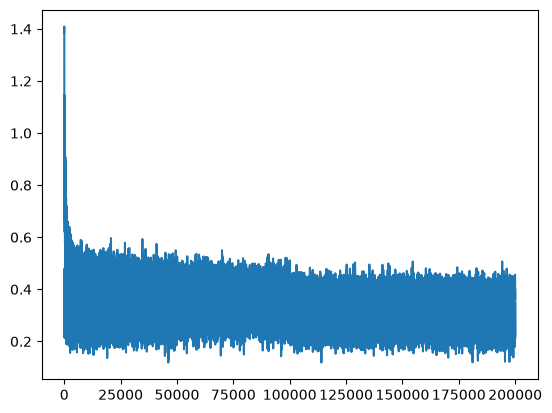

In [201]:
# plt.plot(lri, lossi)
plt.plot(stepi, lossi)

In [202]:
emb = C[Xtr] #(32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.1159, grad_fn=<NllLossBackward0>)

In [203]:
emb = C[Xdev] #(32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1670, grad_fn=<NllLossBackward0>)

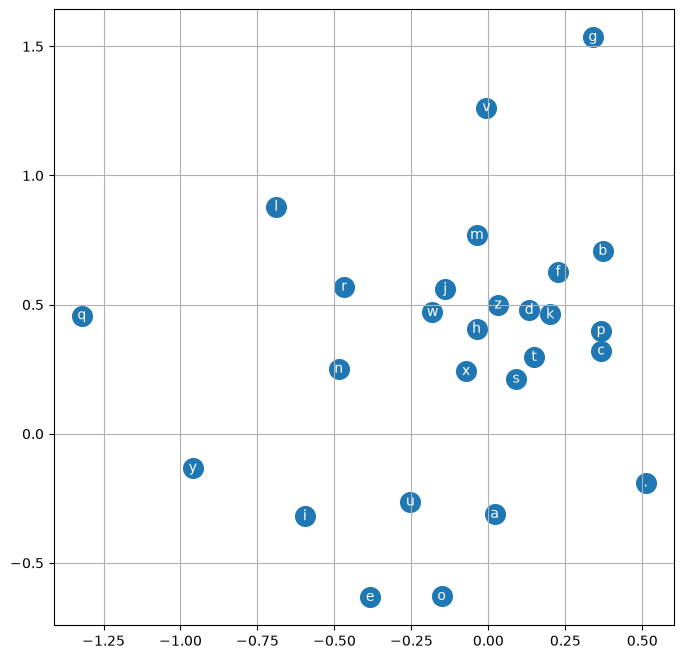

In [170]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i, 0].item(), C[i, 1].item(), itos[i], ha='center', va='center', color='white')
plt.grid('minor')

In [ ]:
# training split (used to train model parameters), dev/validation split (used to train hyperparameter tuning), test split (used to test performace)
# 80%, 10%, 10% 

In [205]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)
for _ in range(20):
    out = []
    context = [0] * block_size # inititalize with ...
    while True:
        emb = C[torch.tensor([context])] # (1, block_size, d)
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    print(''.join(itos[i] for i in out))

carpah.
amelle.
khywari.
reviyah.
cassie.
mahnen.
deliah.
jareei.
nellaiah.
maiir.
kaleigh.
ham.
joce.
quinn.
shon.
emi.
adbi.
watthonielryxi.
jaxen.
ivude.
